In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/processed/conversations_labeled.csv")
shifts = pd.read_csv("data/processed/shifts.csv")

print("Data loaded!")
print("Turns:", len(df))
print("Shifts:", len(shifts))

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/conversations_labeled.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Fix path for notebook
os.chdir("C:/hinglish-sentiment-shift")

# Load data
df = pd.read_csv("data/processed/conversations_labeled.csv")
shifts = pd.read_csv("data/processed/shifts.csv")

print("Data loaded!")
print("Turns:", len(df))
print("Shifts:", len(shifts))

Data loaded!
Turns: 4410
Shifts: 1098


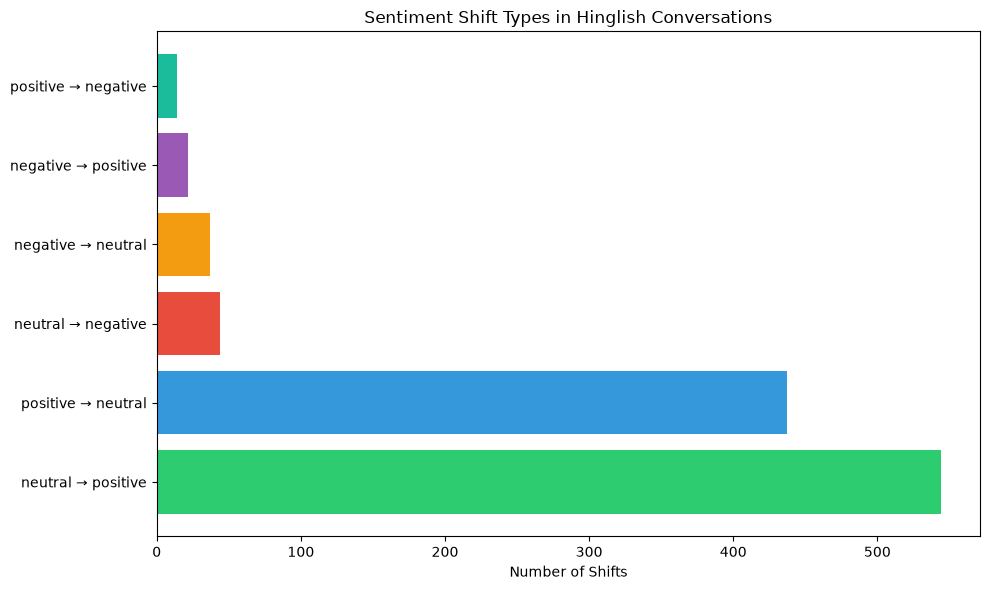

Saved!


In [3]:
# Chart 1 — Shift Types Distribution
plt.figure(figsize=(10, 6))
shift_counts = shifts['shift_type'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
plt.barh(shift_counts.index, shift_counts.values, color=colors)
plt.xlabel('Number of Shifts')
plt.title('Sentiment Shift Types in Hinglish Conversations')
plt.tight_layout()
plt.savefig('outputs/plots/shift_types.png', dpi=150)
plt.show()
print("Saved!")

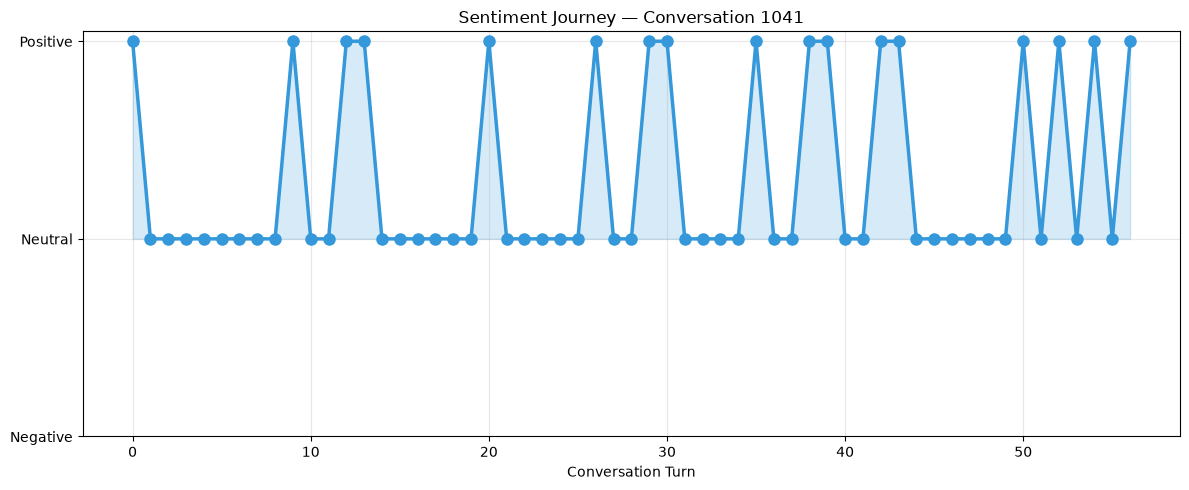

Saved!


In [4]:
# Chart 2 — Sentiment Timeline for most emotional conversation
most_shifts_conv = shifts['conv_id'].value_counts().index[0]
conv_df = df[df['conv_id'] == most_shifts_conv].sort_values('turn')

# Map sentiment to numbers
sentiment_map = {'negative': -1, 'neutral': 0, 'positive': 1}
conv_df['sentiment_num'] = conv_df['sentiment'].map(sentiment_map)

plt.figure(figsize=(12, 5))
plt.plot(conv_df['turn'], conv_df['sentiment_num'], 
         marker='o', linewidth=2.5, color='#3498db', markersize=8)
plt.fill_between(conv_df['turn'], conv_df['sentiment_num'], 
                 alpha=0.2, color='#3498db')
plt.yticks([-1, 0, 1], ['Negative', 'Neutral', 'Positive'])
plt.xlabel('Conversation Turn')
plt.title(f'Sentiment Journey — Conversation {most_shifts_conv}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/plots/sentiment_timeline.png', dpi=150)
plt.show()
print("Saved!")

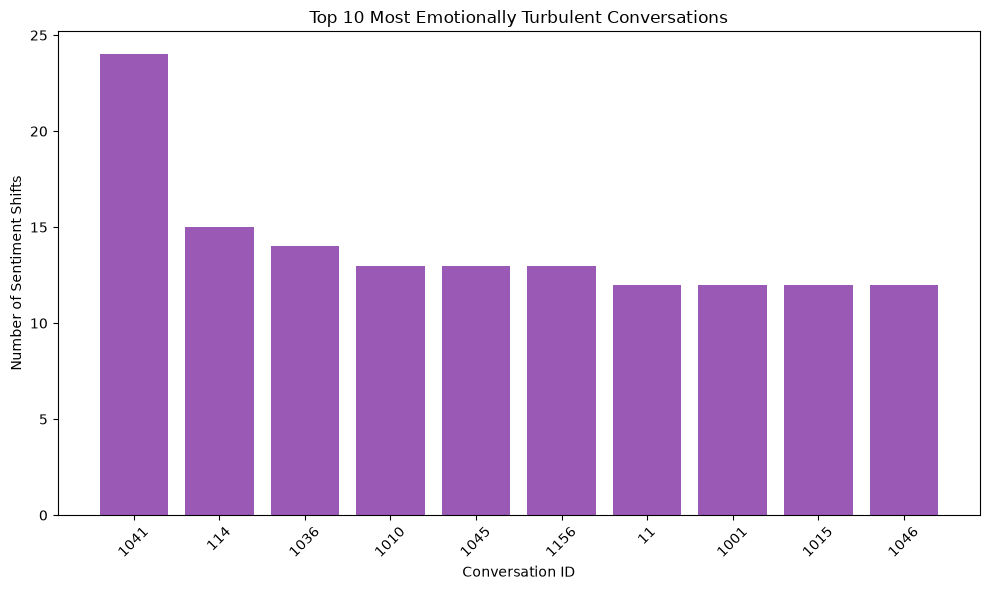

Saved!


In [5]:
# Chart 3 — Top 10 most emotionally turbulent conversations
top_convs = shifts['conv_id'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_convs.index.astype(str), top_convs.values, color='#9b59b6')
plt.xlabel('Conversation ID')
plt.ylabel('Number of Sentiment Shifts')
plt.title('Top 10 Most Emotionally Turbulent Conversations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/plots/top_conversations.png', dpi=150)
plt.show()
print("Saved!")